In [1]:
# import warnings
# # Ignore all warnings
# warnings.filterwarnings('ignore')
# %matplotlib tk
# # Enable interactive mode with a scrollable plot
# %matplotlib qt
# import matplotlib

# import numpy as np
# import glob
# import matplotlib.pyplot as plt
# import sys
# import pickle as pkl
# sys.path.append("..")

# import mne
# from mne.io import RawArray
# from mne.channels import make_standard_montage
# from mne.preprocessing import read_ica
# from mne.io import read_raw_fif
# import gc
# import fooof
# from statsmodels.stats.multitest import multipletests
# from scipy.stats import ttest_rel
# # import mne_microstates
# import pandas as pd
# import seaborn as sns
# import matplotlib.patches as mpatches

# import os
# from scipy.io import loadmat
# import scipy

# import matplotlib.image as mpimg
# from matplotlib.colors import ListedColormap
# import pyxdf
# import socket
# import pickle as pkl
# from pyprep.find_noisy_channels import NoisyChannels
# import copy

# %load_ext autoreload
# %autoreload 2

In [1]:
import warnings
# Ignore all warnings
warnings.filterwarnings('ignore')
%matplotlib tk
# Enable interactive mode with a scrollable plot
%matplotlib qt

import numpy as np
import sys
import pickle as pkl
sys.path.append("..")

import mne
import os
import pyxdf
import socket
import pickle as pkl
from pyprep.find_noisy_channels import NoisyChannels
import copy

%load_ext autoreload
%autoreload 2

In [2]:
sys.path.append('E:/OneDrive - Radboud Universiteit/Documents/')
sys.path.append('E:/OneDrive - Radboud Universiteit/Documents/pdoc_data_analysis/')

current_dir_full = os.getcwd()
current_dir_name = os.path.basename(current_dir_full)

print("Current directory (full):", current_dir_full)
print("Current directory name :", current_dir_name)

# 3. Print parent directory (full path and name only)
parent_dir_full = os.path.dirname(current_dir_full)
parent_dir_name = os.path.basename(parent_dir_full)

print("Parent directory (full):", parent_dir_full)
print("Parent directory name :", parent_dir_name)

Current directory (full): d:\Taran\OneDrive - Radboud Universiteit\Documents\music_doc_study\analysis
Current directory name : analysis
Parent directory (full): d:\Taran\OneDrive - Radboud Universiteit\Documents\music_doc_study
Parent directory name : music_doc_study


In [3]:
device_name = socket.gethostname()
print(device_name)

DESKTOP-I0FNO1F


In [ ]:
sub_id = "sub-10"

if device_name == "LAPTOP-LRI6535I":
    path_analysis_data = "E:/OneDrive - Radboud Universiteit/Documents/PDoCDataAnalysis/analysis_data_new2/"
    path_analysis_data_new = "E:/OneDrive - Radboud Universiteit/Documents/pdoc_data_analysis/analysis_data/"
    data_path1 = f"E:/OneDrive - Radboud Universiteit/Documents/PDoCData/{sub_id}/eeg/sub_10_noise_music.xdf"
    data_path2 = f"E:/OneDrive - Radboud Universiteit/Documents/PDoCData/{sub_id}/eeg/sub_10_last_pink_noise.xdf"
    sys.path.append('E:/OneDrive - Radboud Universiteit/Documents/')
    sys.path.append('E:/OneDrive - Radboud Universiteit/Documents/pdoc_data_analysis/')


if device_name == "DESKTOP-I0FNO1F":
    path_analysis_data = "D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCDataAnalysis/analysis_data_new2/"
    path_analysis_data_new = "D:/Taran/OneDrive - Radboud Universiteit/Documents/pdoc_data_analysis/analysis_data/"
    data_path1 = f"D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCData/{sub_id}/eeg/sub_10_noise_music.xdf"
    data_path2 = f"D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCData/{sub_id}/eeg/sub_10_last_pink_noise.xdf"
    sys.path.append('D:/Taran/OneDrive - Radboud Universiteit/Documents/')
    sys.path.append('D:/Taran/OneDrive - Radboud Universiteit/Documents/pdoc_data_analysis/')


if device_name == "kritrim":
    path_analysis_data = "C:/Users/manda/OneDrive - Radboud Universiteit/Documents/PDoCDataAnalysis/analysis_data_new2/"
    data_path = f"C:/Users/manda/OneDrive - Radboud Universiteit/Documents/PDoCData/{sub_id}/eeg/sub-P001_ses-S001_task-Default_run-001_eeg.xdf"




In [6]:
from helpers.eeg_filter import apply_mne_butterworth
from helpers.extract_data import extract_eeg_segments, ndarray_to_raw, split_and_concatenate_eeg_segments, extract_resting_eeg, trim_raw_seconds, split_music_vs_pinknoise, create_epochs, trim_segments
from helpers.check_remove_artifacts import remove_bad_segments
from helpers.create_mne_onbject import create_mne_raw_with_start_time_restarted

def store_mne_raw(eeg_filtered, path_folder, path_data, ovwrite=False):
    eeg_filtered.save(path_folder + path_data, overwrite=ovwrite)

def load_mne_raw(path_folder, path_data):
    return mne.io.read_raw_fif(path_folder + path_data, preload=True)

Import XDF Data

In [6]:
data_stream1 = pyxdf.load_xdf(data_path1)

2026-01-19 14:42:05,811 - pyxdf.pyxdf - INFO - Importing XDF file D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCData/sub-10/eeg/sub_10_noise_music.xdf...
2026-01-19 14:42:25,381 - pyxdf.pyxdf - INFO -   performing clock synchronization...
2026-01-19 14:42:25,710 - pyxdf.pyxdf - INFO -   performing jitter removal...


In [7]:
data_stream2 = pyxdf.load_xdf(data_path2)

2026-01-19 14:42:26,181 - pyxdf.pyxdf - INFO - Importing XDF file D:/Taran/OneDrive - Radboud Universiteit/Documents/PDoCData/sub-10/eeg/sub_10_last_pink_noise.xdf...
2026-01-19 14:42:28,880 - pyxdf.pyxdf - INFO -   performing clock synchronization...
2026-01-19 14:42:29,101 - pyxdf.pyxdf - INFO -   performing jitter removal...


In [8]:
def get_stream_dict(stream):
    stream_dict = {}

    for i in stream[0]:
        strm_name = i["info"]["name"][0]
        strm_time_series = i["time_series"]
        strm_time_stamps = i["time_stamps"]
        stream_dict[strm_name] = [strm_time_series, strm_time_stamps]

    return stream_dict

data_stream_dict = get_stream_dict(data_stream1)
data_stream_dict2 = get_stream_dict(data_stream2)


In [9]:
data_stream_dict.keys()

dict_keys(['Shimmer3PPG', 'MusicTriggers', 'BioSemi', 'MicrophoneStream', 'Shimmer3GSR', 'ExpConditionTriggers', 'ManualTriggerStream'])

In [10]:
count = 0

for indx, i in enumerate(data_stream_dict['MusicTriggers'][0]):
    start_letters = i[0].split("_")[0]

    if "START" in start_letters or "END" in start_letters:
        print(count, i)
        count += 1

0 ['START_Aca_Lukas_Volis_Li_Me_90.0.wav']
1 ['END_Aca_Lukas_Volis_Li_Me_90.0.wav']
2 ['START_pink_noise_audio_270.0.wav']
3 ['END_pink_noise_audio_270.0.wav']
4 ['START_Aca_Lukas_Volis_Li_Me_191.1.wav']
5 ['END_Aca_Lukas_Volis_Li_Me_191.1.wav']
6 ['START_pink_noise_audio_330.0.wav']
7 ['END_pink_noise_audio_330.0.wav']
8 ['START_Aca_Lukas_Volis_Li_Me_180.0.wav']
9 ['END_Aca_Lukas_Volis_Li_Me_180.0.wav']
10 ['START_pink_noise_audio_150.0.wav']
11 ['END_pink_noise_audio_150.0.wav']
12 ['START_Singah_Mon_Amour_120.0.wav']
13 ['END_Singah_Mon_Amour_120.0.wav']
14 ['START_pink_noise_audio_420.0.wav']
15 ['END_pink_noise_audio_420.0.wav']
16 ['START_Aca_Lukas_Volis_Li_Me_0.0.wav']
17 ['END_Aca_Lukas_Volis_Li_Me_0.0.wav']
18 ['START_pink_noise_audio_210.0.wav']
19 ['END_pink_noise_audio_210.0.wav']
20 ['START_Dino_Merlin_Godinama_30.0.wav']
21 ['END_Dino_Merlin_Godinama_30.0.wav']
22 ['START_pink_noise_audio_120.0.wav']
23 ['END_pink_noise_audio_120.0.wav']
24 ['START_Singah_Mon_Amour_180.0.

In [11]:
print("Data Streams: ", data_stream_dict['ExpConditionTriggers'][0])
print("Rest Init: ", (data_stream_dict['ExpConditionTriggers'][1][1] - data_stream_dict['ExpConditionTriggers'][1][0])/60)
print("Passive 1: ", (data_stream_dict['ExpConditionTriggers'][1][3] - data_stream_dict['ExpConditionTriggers'][1][2])/60)
print("Rest Middle: ", (data_stream_dict['ExpConditionTriggers'][1][5] - data_stream_dict['ExpConditionTriggers'][1][4])/60)
print("Passive 2: ", (data_stream_dict['ExpConditionTriggers'][1][7] - data_stream_dict['ExpConditionTriggers'][1][6])/60)
print("Rest End: ", (data_stream_dict['ExpConditionTriggers'][1][9] - data_stream_dict['ExpConditionTriggers'][1][8])/60)
print("Reward: ", (data_stream_dict['ExpConditionTriggers'][1][11] - data_stream_dict['ExpConditionTriggers'][1][10])/60)


Data Streams:  [['ConditionStart:rest_init'], ['ConditionEnd:rest_init'], ['ConditionStart:passive_1'], ['ConditionEnd:passive_1'], ['ConditionStart:rest_mid'], ['ConditionEnd:rest_mid'], ['ConditionStart:passive_2'], ['ConditionEnd:passive_2'], ['ConditionStart:reward_music'], ['ConditionEnd:reward_music']]
Rest Init:  8.053885053492255
Passive 1:  10.072241294793184
Rest Middle:  4.052186710970758
Passive 2:  10.072716644794308
Rest End:  6.086753698975599


IndexError: index 11 is out of bounds for axis 0 with size 10

In [11]:
eeg = data_stream_dict2['BioSemi']
print(eeg[0].shape)
eeg_reshaped = eeg[0][:, 1:-24].T
print(eeg_reshaped.shape)

(768262, 153)
(128, 768262)


Get Pinknoise EEG

In [12]:
eeg, eeg_timestamps = data_stream_dict2['BioSemi']
eeg_reshaped = eeg[:, 1:-24].T

for indx, stream in enumerate(data_stream_dict2['ExpConditionTriggers'][0]):
    stream_name = stream[0]
    print(stream_name)

    if "pinknoise" in stream_name and "Start" in stream_name:
        print(stream_name)
        start_timestamp = data_stream_dict2['ExpConditionTriggers'][1][indx]

    if "pinknoise" in stream_name and "End" in stream_name:
        print(stream_name)
        end_timestamp = data_stream_dict2['ExpConditionTriggers'][1][indx]


mask = (eeg_timestamps >= start_timestamp) & (eeg_timestamps <= end_timestamp)
eeg_pinknoise = eeg_reshaped[:, mask]

print(eeg_pinknoise.shape)


ConditionStart:pinknoise
ConditionStart:pinknoise
ConditionEnd:pinknoise
ConditionEnd:pinknoise

(128, 747961)


In [13]:
print("Length Pink Noise: ", eeg_pinknoise.shape[1]/2048/60)

Length Pink Noise:  6.086922200520833


Extract EEG Segments

In [14]:
eeg_segs_passive, eeg_segments_freq = extract_eeg_segments(data_stream_dict)

Segment '1 Aca_Lukas_Volis_Li_Me_90.0' duration: 30.007 s
Segment '2 pink_noise_audio_270.0' duration: 30.018 s
Segment '3 Aca_Lukas_Volis_Li_Me_191.1' duration: 30.020 s
Segment '4 pink_noise_audio_330.0' duration: 30.021 s
Segment '5 Aca_Lukas_Volis_Li_Me_180.0' duration: 30.012 s
Segment '6 pink_noise_audio_150.0' duration: 30.008 s
Segment '7 Singah_Mon_Amour_120.0' duration: 30.008 s
Segment '8 pink_noise_audio_420.0' duration: 30.010 s
Segment '9 Aca_Lukas_Volis_Li_Me_0.0' duration: 30.016 s
Segment '10 pink_noise_audio_210.0' duration: 30.008 s
Segment '11 Dino_Merlin_Godinama_30.0' duration: 30.012 s
Segment '12 pink_noise_audio_120.0' duration: 30.021 s
Segment '13 Singah_Mon_Amour_180.0' duration: 30.009 s
Segment '14 pink_noise_audio_570.0' duration: 30.009 s
Segment '15 Aca_Lukas_Volis_Li_Me_30.0' duration: 30.010 s
Segment '16 pink_noise_audio_60.0' duration: 30.010 s
Segment '17 Dino_Merlin_Godinama_207.9' duration: 30.008 s
Segment '18 pink_noise_audio_300.0' duration: 3

In [ ]:
passive_keys = list(eeg_segs_passive.keys())
print("EEG Seg Duration (secs): ", eeg_segs_passive[passive_keys[0]].shape[0]/2048)

exp_duration = 0

for i in eeg_segs_passive:
    exp_duration += eeg_segs_passive[i].shape[0]/2048

print("Total EEG duration across all segments (mins): ", exp_duration/60)

EEG Seg Duration (secs):  30.0068359375
Total EEG duration across all segments (mins):  26.093391927083335


Get Pink Noise Raw

In [16]:
eeg_pinknoise_raw = ndarray_to_raw(eeg_pinknoise, sfreq=eeg_segments_freq)

Creating RawArray with float64 data, n_channels=128, n_times=747961
    Range : 0 ... 747960 =      0.000 ...   365.221 secs
Ready.
Raw created: <RawArray | 128 x 747961 (365.2 s), ~730.6 MiB, data loaded>
   Duration: 365.22 s
   Channels: 128 EEG


Get Rest Raw

In [17]:
eeg_rest_raw = extract_resting_eeg(data_stream_dict)

=== RESTING-STATE → MNE RAW ===

EEG shape      : (5511210, 153)
Sampling rate  : 2047.97 Hz
EEG channels   : 1:129 → 128 ch

REST_INIT: 989645 samples → 483.2s
REST_MID: 497924 samples → 243.1s
ERROR: rest_end missing

Creating MNE RawArray...
Creating RawArray with float64 data, n_channels=128, n_times=1487569
    Range : 0 ... 1487568 =      0.000 ...   726.364 secs
Ready.
Montage 'biosemi128' applied successfully!

SUCCESS: Raw created
   Duration    : 726.4s
   Channels    : 128
   Annotations : 4 (start/end for 2 blocks)


In [18]:
for i in eeg_rest_raw.annotations:
    print(i["description"])

rest_init_start
rest_init_end
rest_mid_start
rest_mid_end


In [19]:
eeg_rest_raw.first_time


0.0

Get Reward and EEG Segs Separated

In [20]:
sfreq = eeg_segments_freq
mont = "biosemi128"
eeg_segs_all, eeg_reward, eeg_segs_raw, eeg_epochs = split_and_concatenate_eeg_segments(eeg_segs_passive, sfreq, montage=mont)

eeg_segs_all shape: (2458637, 128)
eeg_reward shape: (747719, 128)
Creating RawArray with float64 data, n_channels=128, n_times=2458637
    Range : 0 ... 2458636 =      0.000 ...  1200.526 secs
Ready.
Created Raw object: 128 ch, 1200.53s long
Added 39 annotations at segment boundaries
Not setting metadata
40 matching events found
No baseline correction applied
0 projection items activated
Created EpochsArray with 40 epochs (excl. last 2), each 30.0s long


In [21]:
eeg_reawd_transposed = eeg_reward.T
eeg_reward_raw = ndarray_to_raw(eeg_reawd_transposed, sfreq=eeg_segments_freq)
eeg_reward_raw

Creating RawArray with float64 data, n_channels=128, n_times=747719
    Range : 0 ... 747718 =      0.000 ...   365.103 secs
Ready.
Raw created: <RawArray | 128 x 747719 (365.1 s), ~730.3 MiB, data loaded>
   Duration: 365.10 s
   Channels: 128 EEG


<RawArray | 128 x 747719 (365.1 s), ~730.3 MiB, data loaded>

In [22]:
print(eeg_reward_raw.get_data().shape[1]/2048/60)


6.084952799479167


### Resample Data

In [23]:
eeg_pinknoise_raw.resample(sfreq=512.0, npad='auto')
eeg_segs_raw.resample(sfreq=512.0, npad='auto')
eeg_rest_raw.resample(sfreq=512.0, npad='auto')
eeg_reward_raw.resample(sfreq=512.0, npad='auto')

<RawArray | 128 x 186933 (365.1 s), ~182.7 MiB, data loaded>

#### Merge All Data

In [25]:
print(eeg_pinknoise_raw.first_time)
print(eeg_segs_raw.first_time)
print(eeg_rest_raw.first_time)
print(eeg_reward_raw.first_time)

0.0
0.0
0.0
0.0


Add annotations fopr last Segment into EEG Segments

In [26]:
onset_list = []
duration_list = []
description_list = []

for ann in eeg_segs_raw.annotations:
    onset_list.append(ann["onset"])
    duration_list.append(ann["duration"])
    description_list.append(ann["description"])

onset_list.append(eeg_segs_raw.times[-1])
duration_list.append(0.5)
description_list.append("pink_noise_last")
print(len(description_list))

annots = mne.annotations.Annotations(
    onset=onset_list,
    duration=duration_list,
    description=description_list)

eeg_segs_raw.set_annotations(annots)

40


C:\Users\specsdcn\AppData\Local\Temp\ipykernel_1396\2565528879.py:20: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  eeg_segs_raw.set_annotations(annots)


<RawArray | 128 x 614670 (1200.5 s), ~600.4 MiB, data loaded>

Divide Segs Data into 2 blocks

In [27]:
print(len(eeg_segs_raw.annotations))

40


In [28]:
block_1_last_ann_indx = int(len(eeg_segs_raw.annotations)/2 -1)
block_1_end = eeg_segs_raw.annotations[block_1_last_ann_indx]["onset"]
block_2_start = eeg_segs_raw.annotations[block_1_last_ann_indx+1]["onset"]
block_2_end = eeg_segs_raw.annotations[-1]["onset"] - 0.00001 # Small buffer

eeg_segs_raw_block_1 = eeg_segs_raw.copy().crop(tmin=0.0, tmax=block_1_end)
eeg_segs_raw_block_2 = eeg_segs_raw.copy().crop(tmin=block_1_end, tmax=block_2_end)

In [29]:
print(len(eeg_segs_raw_block_1.annotations))
print(len(eeg_segs_raw_block_2.annotations))

20
21


In [30]:
print(eeg_segs_raw_block_1.annotations[-1]["description"])
print(eeg_segs_raw_block_2.annotations[0]["description"])

Boundary_20_pink_noise_audio_480.0
Boundary_20_pink_noise_audio_480.0


In [31]:
eeg_segs_raw_block_2.first_time

np.float64(600.228515625)

In [32]:
onset_list = []
duration_list = []
description_list = []
raw_annots = eeg_segs_raw_block_2.annotations
offset = eeg_segs_raw_block_2.first_time

# annots_empty = mne.annotations.Annotations(
#     onset=onset_list,
#     duration=duration_list,
#     description=description_list)

for i in range(1, len(raw_annots)): #Remove the first annotation
    description_list.append(raw_annots[i]["description"])
    onset = raw_annots[i]["onset"] - offset
    onset_list.append(onset)
    duration_list.append(raw_annots[i]["duration"])

annots = mne.annotations.Annotations(
    onset=onset_list,
    duration=duration_list,
    description=description_list)

eeg_segs_raw_block_2.set_annotations(annots)

<RawArray | 128 x 307353 (600.3 s), ~300.3 MiB, data loaded>

In [33]:
eeg_segs_raw_block_2.annotations[0]

OrderedDict([('onset', np.float64(630.245617625)),
             ('duration', np.float64(0.5)),
             ('description',
              np.str_('Boundary_21_Dino_Merlin_Godinama_180.0')),
             ('orig_time', None),
             ('extras', {})])

Segment Rest Data

In [34]:
ann = eeg_rest_raw.annotations

segments = []          # store (start, end) time pairs
current_start = None   # keep track of last start
len_rest = eeg_rest_raw.times[-1]

for desc, onset, duration in zip(ann.description, ann.onset, ann.duration):
    if desc.endswith("start"):
        current_start = onset

    elif desc.endswith("end") and current_start is not None:
        end_time = onset
        segments.append((current_start, end_time))
        current_start = None  # reset for next pair

raw_rest_segments = []

for start, end in segments:
    if end > len_rest:
        end = len_rest - 0.1  # small buffer to avoid exceeding data length
    seg = eeg_rest_raw.copy().crop(tmin=start, tmax=end)
    raw_rest_segments.append(seg)

rest_segment_dict = {
    f"segment_{i+1}": seg for i, seg in enumerate(raw_rest_segments)
}

print(f"Found {len(raw_rest_segments)} segments.")
for name, seg in rest_segment_dict.items():
    print(name, seg)


Found 2 segments.
segment_1 <RawArray | 128 x 247416 (483.2 s), ~241.8 MiB, data loaded>
segment_2 <RawArray | 128 x 124433 (243.0 s), ~121.7 MiB, data loaded>


In [35]:
montage_name = "biosemi128"
channels = 128
rest_init = rest_segment_dict["segment_1"].copy()
rest_mid = create_mne_raw_with_start_time_restarted(rest_segment_dict["segment_2"], montage=montage_name, channel_n=channels)

Creating RawArray with float64 data, n_channels=128, n_times=124433
    Range : 0 ... 124432 =      0.000 ...   243.031 secs
Ready.


Add Annotations to Rest, Reward and PinkNoise

In [36]:
def reset_rest_annotations(raw, paradigm):
    onset_list = []
    duration_list = []
    description_list = []

    duration = 0.5

    # if len(raw_annots) > 1:
    #     for ann in raw_annots:
    #         ann_desc = ann["description"]

    #         if paradigm in ann_desc:
    #             onset_list.append(ann["onset"])
    #             duration_list.append(duration)
    #             description_list.append(ann["description"])

    # else:
    
    onset_start = 0.0
    onset_end = raw.times[-1]

    onset_list = [onset_start, onset_end]
    duration_list = [duration, duration]

    description_start = paradigm + "_start"
    description_end = paradigm + "_end"
    description_list = [description_start, description_end]

    annots = mne.annotations.Annotations(
        onset=onset_list,
        duration=duration_list,
        description=description_list)

    
    return annots
 
annots_rest_init = reset_rest_annotations(rest_init, "rest_init")
annots_rest_mid = reset_rest_annotations(rest_mid, "rest_mid")
        
               
rest_init.set_annotations(annots_rest_init)
rest_mid.set_annotations(annots_rest_mid)


C:\Users\specsdcn\AppData\Local\Temp\ipykernel_1396\3007921512.py:41: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  rest_init.set_annotations(annots_rest_init)
C:\Users\specsdcn\AppData\Local\Temp\ipykernel_1396\3007921512.py:42: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  rest_mid.set_annotations(annots_rest_mid)


<RawArray | 128 x 124433 (243.0 s), ~121.7 MiB, data loaded>

In [37]:
for ann in rest_mid.annotations:
    print(ann["onset"], ann["description"])

0.0 rest_mid_start
243.03125 rest_mid_end


In [38]:
annots_reward = reset_rest_annotations(eeg_reward_raw, "reward")

print(annots_reward[0], annots_reward[1]) 

eeg_reward_raw.set_annotations(annots_reward)


OrderedDict([('onset', np.float64(0.0)), ('duration', np.float64(0.5)), ('description', np.str_('reward_start')), ('orig_time', None), ('extras', {})]) OrderedDict([('onset', np.float64(365.1015625)), ('duration', np.float64(0.5)), ('description', np.str_('reward_end')), ('orig_time', None), ('extras', {})])


C:\Users\specsdcn\AppData\Local\Temp\ipykernel_1396\314819100.py:5: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  eeg_reward_raw.set_annotations(annots_reward)


<RawArray | 128 x 186933 (365.1 s), ~182.7 MiB, data loaded>

In [39]:
annots_pinknoise = reset_rest_annotations(eeg_pinknoise_raw, "pinknoise")

print(annots_pinknoise[0], annots_pinknoise[1]) 

eeg_pinknoise_raw.set_annotations(annots_pinknoise)

OrderedDict([('onset', np.float64(0.0)), ('duration', np.float64(0.5)), ('description', np.str_('pinknoise_start')), ('orig_time', None), ('extras', {})]) OrderedDict([('onset', np.float64(365.21875)), ('duration', np.float64(0.5)), ('description', np.str_('pinknoise_end')), ('orig_time', None), ('extras', {})])


C:\Users\specsdcn\AppData\Local\Temp\ipykernel_1396\3134807547.py:5: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  eeg_pinknoise_raw.set_annotations(annots_pinknoise)


<RawArray | 128 x 186993 (365.2 s), ~182.8 MiB, data loaded>

#### Concatenate All Data

In [40]:
print(rest_init.first_time)
print(eeg_segs_raw_block_1.first_time)
print(rest_mid.first_time)
print(eeg_segs_raw_block_2.first_time)
print(eeg_pinknoise_raw.first_time)
print(eeg_reward_raw.first_time)

0.0
0.0
0.0
600.228515625
0.0
0.0


In [41]:
print(rest_init.times[-1]/60)
print(eeg_segs_raw_block_1.times[-1]/60)
print(rest_mid.times[-1]/60)
print(eeg_segs_raw_block_2.times[-1]/60)
print(eeg_pinknoise_raw.times[-1]/60)
print(eeg_reward_raw.times[-1]/60)

8.053873697916666
10.00380859375
4.050520833333334
10.004947916666667
6.086979166666667
6.085026041666667


Reset First time for Segment 2 (Passive 2) Data

In [42]:
eeg_segs_raw_block_2 = create_mne_raw_with_start_time_restarted(eeg_segs_raw_block_2, montage=montage_name, channel_n=channels)


Creating RawArray with float64 data, n_channels=128, n_times=307353
    Range : 0 ... 307352 =      0.000 ...   600.297 secs
Ready.


In [43]:
raw_all_list = [rest_init, eeg_segs_raw_block_1, rest_mid, eeg_segs_raw_block_2, eeg_reward_raw, eeg_pinknoise_raw]

all_parads_raw = mne.concatenate_raws(raw_all_list)

In [44]:
for ann in all_parads_raw.annotations:
    print(ann["description"])

rest_init_start
rest_init_end
BAD boundary
EDGE boundary
Boundary_1_Aca_Lukas_Volis_Li_Me_90.0
Boundary_2_pink_noise_audio_270.0
Boundary_3_Aca_Lukas_Volis_Li_Me_191.1
Boundary_4_pink_noise_audio_330.0
Boundary_5_Aca_Lukas_Volis_Li_Me_180.0
Boundary_6_pink_noise_audio_150.0
Boundary_7_Singah_Mon_Amour_120.0
Boundary_8_pink_noise_audio_420.0
Boundary_9_Aca_Lukas_Volis_Li_Me_0.0
Boundary_10_pink_noise_audio_210.0
Boundary_11_Dino_Merlin_Godinama_30.0
Boundary_12_pink_noise_audio_120.0
Boundary_13_Singah_Mon_Amour_180.0
Boundary_14_pink_noise_audio_570.0
Boundary_15_Aca_Lukas_Volis_Li_Me_30.0
Boundary_16_pink_noise_audio_60.0
Boundary_17_Dino_Merlin_Godinama_207.9
Boundary_18_pink_noise_audio_300.0
Boundary_19_Dino_Merlin_Godinama_120.0
Boundary_20_pink_noise_audio_480.0
BAD boundary
EDGE boundary
rest_mid_start
rest_mid_end
BAD boundary
EDGE boundary
Boundary_21_Dino_Merlin_Godinama_180.0
Boundary_22_pink_noise_audio_390.0
Boundary_23_Dino_Merlin_Godinama_0.0
Boundary_24_pink_noise_audio

In [45]:
def remove_bad_edge_annotations(raw):
    onset_list = []
    duration_list = []
    description_list = []
    raw_annots = raw.annotations

    for ann in raw_annots:
        if "EDGE" not in ann["description"] and "BAD"  not in ann["description"]:
            onset_list.append(ann["onset"])
            duration_list.append(duration)
            description_list.append(ann["description"])


    annots = mne.annotations.Annotations(
        onset=onset_list,
        duration=duration_list,
        description=description_list)

    return annots

annots_all_segs = remove_bad_edge_annotations(all_parads_raw)

In [46]:

for ann in annots_all_segs:
    print(ann["description"])

rest_init_start
rest_init_end
Boundary_1_Aca_Lukas_Volis_Li_Me_90.0
Boundary_2_pink_noise_audio_270.0
Boundary_3_Aca_Lukas_Volis_Li_Me_191.1
Boundary_4_pink_noise_audio_330.0
Boundary_5_Aca_Lukas_Volis_Li_Me_180.0
Boundary_6_pink_noise_audio_150.0
Boundary_7_Singah_Mon_Amour_120.0
Boundary_8_pink_noise_audio_420.0
Boundary_9_Aca_Lukas_Volis_Li_Me_0.0
Boundary_10_pink_noise_audio_210.0
Boundary_11_Dino_Merlin_Godinama_30.0
Boundary_12_pink_noise_audio_120.0
Boundary_13_Singah_Mon_Amour_180.0
Boundary_14_pink_noise_audio_570.0
Boundary_15_Aca_Lukas_Volis_Li_Me_30.0
Boundary_16_pink_noise_audio_60.0
Boundary_17_Dino_Merlin_Godinama_207.9
Boundary_18_pink_noise_audio_300.0
Boundary_19_Dino_Merlin_Godinama_120.0
Boundary_20_pink_noise_audio_480.0
rest_mid_start
rest_mid_end
Boundary_21_Dino_Merlin_Godinama_180.0
Boundary_22_pink_noise_audio_390.0
Boundary_23_Dino_Merlin_Godinama_0.0
Boundary_24_pink_noise_audio_330.0_1
Boundary_25_Dino_Merlin_Godinama_207.9_1
Boundary_26_pink_noise_audio_0.

In [47]:
all_parads_raw.set_annotations(annots_all_segs)

<RawArray | 128 x 1360446 (2657.1 s), ~1.30 GiB, data loaded>

### Re-reference EEG

In [48]:
all_parads_raw_reref = all_parads_raw.copy()
all_parads_raw_reref.set_eeg_reference(ref_channels='average')

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


<RawArray | 128 x 1360446 (2657.1 s), ~1.30 GiB, data loaded>

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 4.000 (s)
Plotting power spectral density (dB=True).


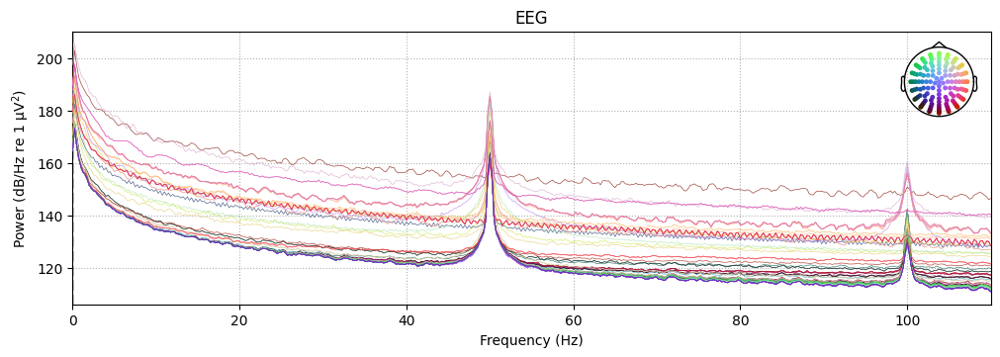

In [49]:
all_parads_raw_reref.plot_psd(fmax=110)

Band Pass Filtering

In [50]:
all_parads_raw_filt = apply_mne_butterworth(
    all_parads_raw_reref,
    apply_notch=True, 
    notch_freq=50,  # Notch filter frequencies
    notch_order=4,  

    filter_type='bandpass', 
    cutoff_freq_high=80, # High-pass cutoff
    cutoff_freq_low=0.5, # Low-pass cutoff

    order_low=6,
    order_high=4,
)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 48 - 52 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 47.88
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 46.88 Hz)
- Upper passband edge: 52.12 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 53.12 Hz)
- Filter length: 845 samples (1.650 s)

Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 0.5 Hz

IIR filter parameters
---------------------
Butterworth highpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 12 (effective, after forward-backward)
- Cutoff at 0.50 Hz: -6.02 dB

Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 80 Hz

FIR filter parameters
---------------------
Designing a one-pass

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 4.000 (s)
Plotting power spectral density (dB=True).


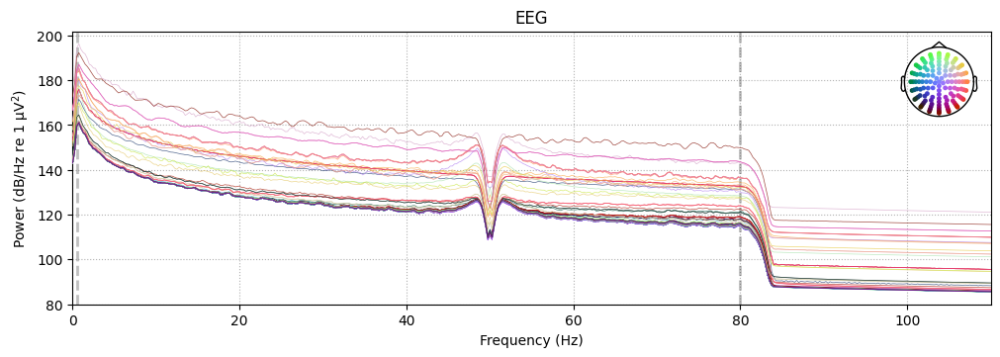

In [51]:
all_parads_raw_filt.plot_psd(fmax=110)

#### REMOVE BAD CHANNELS AND SEGMENTS

In [52]:
nd_all = NoisyChannels(all_parads_raw_filt, random_state=42)
nd_all.find_all_bads()

bad_ch_dict = nd_all.get_bads(as_dict=1)
bad_ch_dict["bad_all"].sort()
bad_ch_dict["bad_all"]

NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Setting up high-pass filter at 1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Filter length: 1691 samples (3.303 s)

Executing RANSAC
This may take a while, so be patient...


c:\Users\specsdcn\anaconda3\envs\pdoc\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████|  : 531/531 [02:03<00:00,    4.29it/s]


RANSAC done!


['A13',
 'A26',
 'B14',
 'B15',
 'B16',
 np.str_('B20'),
 'B21',
 'B23',
 'B24',
 'B25',
 'B26',
 'B27',
 'B28',
 'B29',
 'B30',
 'B31',
 'B6',
 'B7',
 'B8',
 'B9',
 'C13',
 'C4',
 'C5',
 'C6',
 'C7',
 'C8',
 'D12']

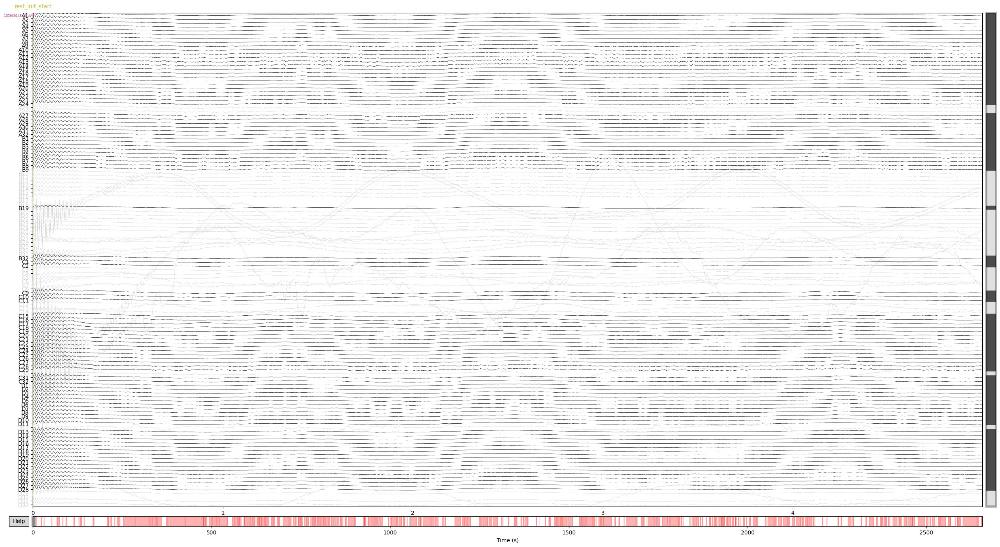

In [15]:
all_parads_raw_filt.plot(n_channels=128, duration=5, scalings='auto', clipping=None, butterfly=0)

In [55]:
path_analysis_data_new

'D:/Taran/OneDrive - Radboud Universiteit/Documents/pdoc_data_analysis/analysis_data/'

Store/Load Data

In [26]:
eeg_filtered_file = "sub-10/eeg_filtered.fif"
store_mne_raw(all_parads_raw_filt, path_analysis_data_new, eeg_filtered_file, ovwrite=1)

Overwriting existing file.
Writing D:\Taran\OneDrive - Radboud Universiteit\Documents\pdoc_data_analysis\analysis_data\sub-10\eeg_filtered.fif
Overwriting existing file.


C:\Users\specsdcn\AppData\Local\Temp\ipykernel_15612\2535818631.py:7: RuntimeWarning: This filename (D:\Taran\OneDrive - Radboud Universiteit\Documents\pdoc_data_analysis\analysis_data\sub-10\eeg_filtered.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  eeg_filtered.save(path_folder + path_data, overwrite=ovwrite)


Closing D:\Taran\OneDrive - Radboud Universiteit\Documents\pdoc_data_analysis\analysis_data\sub-10\eeg_filtered.fif
[done]


In [14]:
eeg_filtered_file = "sub-10/eeg_filtered.fif"
all_parads_raw_filt = load_mne_raw(path_analysis_data_new, eeg_filtered_file)


Opening raw data file D:/Taran/OneDrive - Radboud Universiteit/Documents/pdoc_data_analysis/analysis_data/sub-10/eeg_filtered.fif...


C:\Users\specsdcn\AppData\Local\Temp\ipykernel_19912\2535818631.py:10: RuntimeWarning: This filename (D:/Taran/OneDrive - Radboud Universiteit/Documents/pdoc_data_analysis/analysis_data/sub-10/eeg_filtered.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(path_folder + path_data, preload=True)


    Range : 0 ... 1360445 =      0.000 ...  2657.119 secs
Ready.
Reading 0 ... 1360445  =      0.000 ...  2657.119 secs...


In [24]:
def check_annotation_overlaps(raw):
    """
    Check for overlapping annotations in an MNE Raw object.
    
    Parameters
    ----------
    raw : mne.io.Raw
        The Raw object containing annotations.
    
    Returns
    -------
    has_overlaps : bool
        True if any overlaps are found, False otherwise.
    """
    anns = raw.annotations
    
    if len(anns) < 2:
        print("Fewer than 2 annotations — no overlaps possible.")
        return
    
    # Create a sorted list of annotations by onset
    ann_list = sorted(
        zip(anns.onset, anns.duration, anns.description),
        key=lambda x: x[0]  # sort by onset
    )

    overlap_dict = {}    
    for i in range(len(ann_list) - 1):
        onset1, dur1, desc1 = ann_list[i]
        end1 = onset1 + dur1
        
        onset2, dur2, desc2 = ann_list[i+1]
        
        if end1 > onset2:
            print(f"Overlap detected between:")
            print(f"  - Annotation 1: onset={onset1:.2f}s, duration={dur1:.2f}s, desc='{desc1}'")
            print(f"  - Annotation 2: onset={onset2:.2f}s, duration={dur2:.2f}s, desc='{desc2}'")
            print(f"  (Overlap amount: {end1 - onset2:.2f}s)")
            print("---")
            has_overlaps = True

            overlap_dict[f"{desc1}_and_{desc2}"] = (onset1, end1, onset2, onset2 + dur2)

    return overlap_dict

# Example usage:
# raw = your MNE Raw object (e.g., mne.io.read_raw_fif('your_file.fif', preload=True))
overlaps_dict = check_annotation_overlaps(all_parads_raw_filt)


In [25]:
overlaps_dict

{}

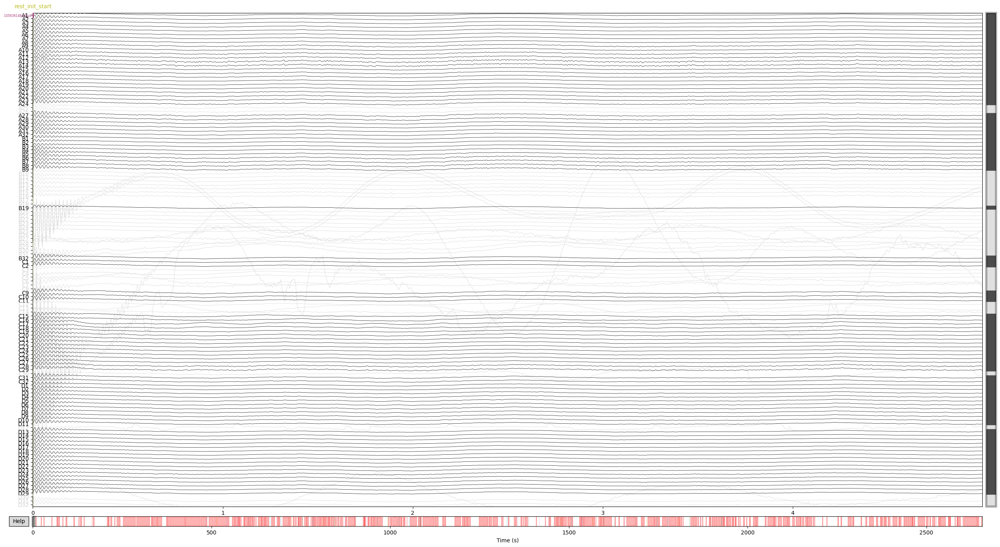

In [23]:
all_parads_raw_filt.plot(n_channels=128, duration=5, scalings='auto', clipping=None, butterfly=0)

Remove Bad Segments

In [27]:
all_parads_raw_badsegs_removed = remove_bad_segments(all_parads_raw_filt)

Original duration: 2657.12 sec
Corrected duration: 1369.51 sec


In [ ]:
count_ann = 0

for ann in all_parads_raw_badsegs_removed.annotations:
    if "BAD" not in ann["description"] and "EDGE" not in ann["description"]:
        count_ann += 1
        print(ann["description"], ann["onset"])

print("Annotations after bad segment removal: ", count_ann)
    

rest_init_start 0.0
rest_init_end 246.957032
Boundary_1_Aca_Lukas_Volis_Li_Me_90.0 255.489746
Boundary_2_pink_noise_audio_270.0 258.536682
Boundary_3_Aca_Lukas_Volis_Li_Me_191.1 272.910218
Boundary_4_pink_noise_audio_330.0 283.581177
Boundary_5_Aca_Lukas_Volis_Li_Me_180.0 297.321411
Boundary_6_pink_noise_audio_150.0 307.764771
Boundary_7_Singah_Mon_Amour_120.0 324.210145
Boundary_8_pink_noise_audio_420.0 333.824891
Boundary_9_Aca_Lukas_Volis_Li_Me_0.0 353.116455
Boundary_10_pink_noise_audio_210.0 371.634521
Boundary_11_Dino_Merlin_Godinama_30.0 382.115478
Boundary_12_pink_noise_audio_120.0 390.234192
Boundary_13_Singah_Mon_Amour_180.0 413.595031
Boundary_14_pink_noise_audio_570.0 420.87384
Boundary_15_Aca_Lukas_Volis_Li_Me_30.0 445.422729
Boundary_16_pink_noise_audio_60.0 457.776245
Boundary_17_Dino_Merlin_Godinama_207.9 476.403748
Boundary_18_pink_noise_audio_300.0 490.087341
Boundary_19_Dino_Merlin_Godinama_120.0 507.123047
Boundary_20_pink_noise_audio_480.0 514.791992
rest_mid_start

TRIM AROUND TRIGGERS

In [81]:
def trim_all_raw(raw_segs_corr, seconds_to_trim=1, montage="biosemi128"):
    raw = raw_segs_corr.copy()
    all_anns = raw.annotations

    # Filter valid boundary annotations
    boundary_anns = [
        a for a in all_anns
        if "start" not in a["description"] and "BAD" not in a["description"] and "EDGE" not in a["description"] and "event" not in a["description"]]

    if len(boundary_anns) == 0:
        raise RuntimeError("No valid boundary annotations found.")

    segments = []
    onset_list = []
    duration_list = []
    description_list = []
    
    # last_ann = len(boundary_anns)
    count_ann = 0
    t_start = 0.0
    # last_time = 0
    offset = raw.first_time
    print("Raw first time: ", offset)

    if offset < 0:
        print("Offset below 0s, cannot proceed.")
        return
    
    onset_offset = seconds_to_trim * 2

    for a in boundary_anns:
        t_end = a["onset"] - offset
        desc = a["description"]

        if t_end <= t_start:
            continue

        print(f"Segment: {desc}, {t_start:.2f}s to {t_end:.2f}s")

        # Crop the segment
        seg = raw.copy().crop(tmin=t_start, tmax=t_end, include_tmax=False)

        seg_trimmed_start = trim_raw_seconds(seg, seconds_to_trim, from_end=False)
        seg_trimmed_end = trim_raw_seconds(seg_trimmed_start, seconds_to_trim, from_end=True)

        segments.append(seg_trimmed_end.get_data())

        # if count_ann >= len(boundary_anns) - 1:
        #     onset_list.append(t_end - (seconds_to_trim*2) - 0.01) #Small Buffer to not exceed the max val.

        # else:
        if count_ann < len(boundary_anns) - 1:
            onset_list.append(t_end - onset_offset)           
            duration_list.append(a['duration'])
            description_list.append(desc)

        # music_last_time += seg.get_data().shape[1] / seg.info['sfreq']
        
        print("Onset added: ", onset_list[-1])
        count_ann += 1
        onset_offset += seconds_to_trim * 2
        t_start = t_end

    info = copy.deepcopy(raw.info)
    
    seg_concat = np.concatenate(segments, axis=1)
    raw_concat = mne.io.RawArray(seg_concat, info)
    # raw_concat.info = info
    raw_concat.set_montage(montage)

    ## Add a trigger for the last paradigm (Pink Noise End)
    onset_list.append(raw_concat.times[-1])
    duration_list.append(0.01)
    description_list.append("pink_noise_continuous_end")

    annots = mne.annotations.Annotations(
        onset=onset_list,
        duration=duration_list,
        description=description_list)
    
    raw_concat.set_annotations(annots)

    return raw_concat

In [82]:
all_parads_raw_trimmed = trim_all_raw(all_parads_raw_badsegs_removed)

Raw first time:  0.0
Segment: rest_init_end, 0.00s to 246.96s
Onset added:  244.957032
Segment: Boundary_1_Aca_Lukas_Volis_Li_Me_90.0, 246.96s to 255.49s
Onset added:  251.489746
Segment: Boundary_2_pink_noise_audio_270.0, 255.49s to 258.54s
Onset added:  252.53668199999998
Segment: Boundary_3_Aca_Lukas_Volis_Li_Me_191.1, 258.54s to 272.91s
Onset added:  264.910218
Segment: Boundary_4_pink_noise_audio_330.0, 272.91s to 283.58s
Onset added:  273.581177
Segment: Boundary_5_Aca_Lukas_Volis_Li_Me_180.0, 283.58s to 297.32s
Onset added:  285.321411
Segment: Boundary_6_pink_noise_audio_150.0, 297.32s to 307.76s
Onset added:  293.764771
Segment: Boundary_7_Singah_Mon_Amour_120.0, 307.76s to 324.21s
Onset added:  308.210145
Segment: Boundary_8_pink_noise_audio_420.0, 324.21s to 333.82s
Onset added:  315.824891
Segment: Boundary_9_Aca_Lukas_Volis_Li_Me_0.0, 333.82s to 353.12s
Onset added:  333.116455
Segment: Boundary_10_pink_noise_audio_210.0, 353.12s to 371.63s
Onset added:  349.634521
Segment

C:\Users\specsdcn\AppData\Local\Temp\ipykernel_15612\3676870126.py:81: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  raw_concat.set_annotations(annots)


In [83]:
count_ann = 0

for ann in all_parads_raw_trimmed.annotations:
    # if "BAD" not in ann["description"] and "EDGE" not in ann["description"]:
    count_ann += 1
    print(ann["description"], ann["onset"])

print("Annotations after bad segment removal: ", count_ann)
    

rest_init_end 244.957032
Boundary_1_Aca_Lukas_Volis_Li_Me_90.0 251.489746
Boundary_2_pink_noise_audio_270.0 252.536682
Boundary_3_Aca_Lukas_Volis_Li_Me_191.1 264.910218
Boundary_4_pink_noise_audio_330.0 273.581177
Boundary_5_Aca_Lukas_Volis_Li_Me_180.0 285.321411
Boundary_6_pink_noise_audio_150.0 293.764771
Boundary_7_Singah_Mon_Amour_120.0 308.210145
Boundary_8_pink_noise_audio_420.0 315.824891
Boundary_9_Aca_Lukas_Volis_Li_Me_0.0 333.116455
Boundary_10_pink_noise_audio_210.0 349.634521
Boundary_11_Dino_Merlin_Godinama_30.0 358.115478
Boundary_12_pink_noise_audio_120.0 364.234192
Boundary_13_Singah_Mon_Amour_180.0 385.595031
Boundary_14_pink_noise_audio_570.0 390.87384
Boundary_15_Aca_Lukas_Volis_Li_Me_30.0 413.422729
Boundary_16_pink_noise_audio_60.0 423.776245
Boundary_17_Dino_Merlin_Godinama_207.9 440.403748
Boundary_18_pink_noise_audio_300.0 452.087341
Boundary_19_Dino_Merlin_Godinama_120.0 467.123047
Boundary_20_pink_noise_audio_480.0 472.791992
rest_mid_end 591.947266
Boundary_2

Interpolate

In [84]:
all_parads_raw_trimmed.interpolate_bads()

Setting channel interpolation method to {'eeg': 'spline'}.
Interpolating bad channels.
    Automatic origin fit: head of radius 95.0 mm
Computing interpolation matrix from 90 sensor positions
Interpolating 38 sensors


<RawArray | 128 x 656134 (1281.5 s), ~640.9 MiB, data loaded>

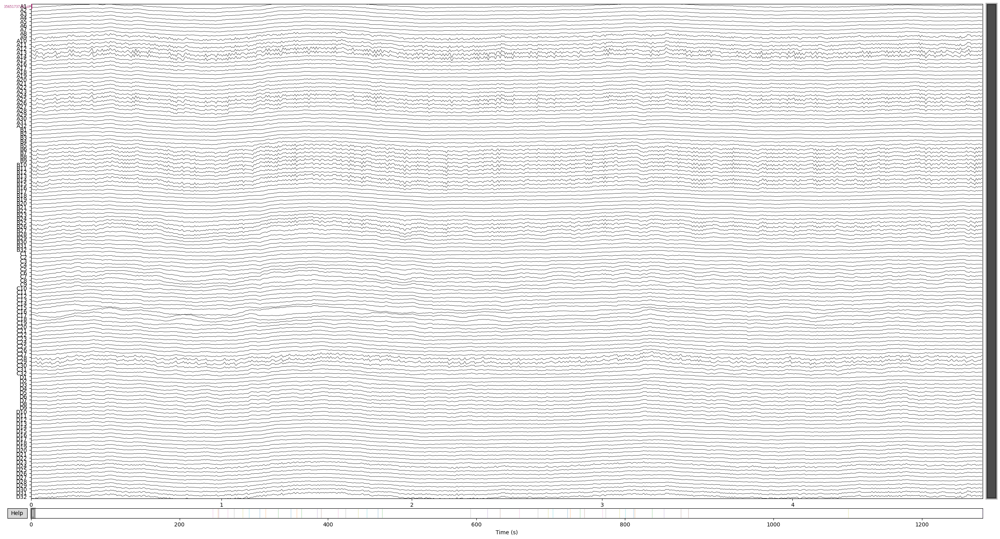

In [85]:
all_parads_raw_trimmed.plot(n_channels=128, duration=5, scalings='auto', clipping=None, butterfly=0)

Store and Load Segment Data

In [ ]:
# eeg_filtered_file = "sub-10/eeg_filtered_trimmed.fif"
# store_mne_raw(all_parads_raw_trimmed, path_analysis_data_new, eeg_filtered_file, ovwrite=0)



Writing D:\Taran\OneDrive - Radboud Universiteit\Documents\pdoc_data_analysis\analysis_data\sub-10\eeg_filtered_trimmed.fif


C:\Users\specsdcn\AppData\Local\Temp\ipykernel_15612\2535818631.py:7: RuntimeWarning: This filename (D:\Taran\OneDrive - Radboud Universiteit\Documents\pdoc_data_analysis\analysis_data\sub-10\eeg_filtered_trimmed.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  eeg_filtered.save(path_folder + path_data, overwrite=ovwrite)


Closing D:\Taran\OneDrive - Radboud Universiteit\Documents\pdoc_data_analysis\analysis_data\sub-10\eeg_filtered_trimmed.fif
[done]


In [6]:
eeg_filtered_file = "sub-10/eeg_filtered_trimmed.fif"
all_parads_raw_trimmed = load_mne_raw(path_analysis_data_new, eeg_filtered_file)

Opening raw data file D:/Taran/OneDrive - Radboud Universiteit/Documents/pdoc_data_analysis/analysis_data/sub-10/eeg_filtered_trimmed.fif...


C:\Users\specsdcn\AppData\Local\Temp\ipykernel_19912\2535818631.py:10: RuntimeWarning: This filename (D:/Taran/OneDrive - Radboud Universiteit/Documents/pdoc_data_analysis/analysis_data/sub-10/eeg_filtered_trimmed.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  return mne.io.read_raw_fif(path_folder + path_data, preload=True)


    Range : 0 ... 656133 =      0.000 ...  1281.510 secs
Ready.
Reading 0 ... 656133  =      0.000 ...  1281.510 secs...


Using matplotlib as 2D backend.


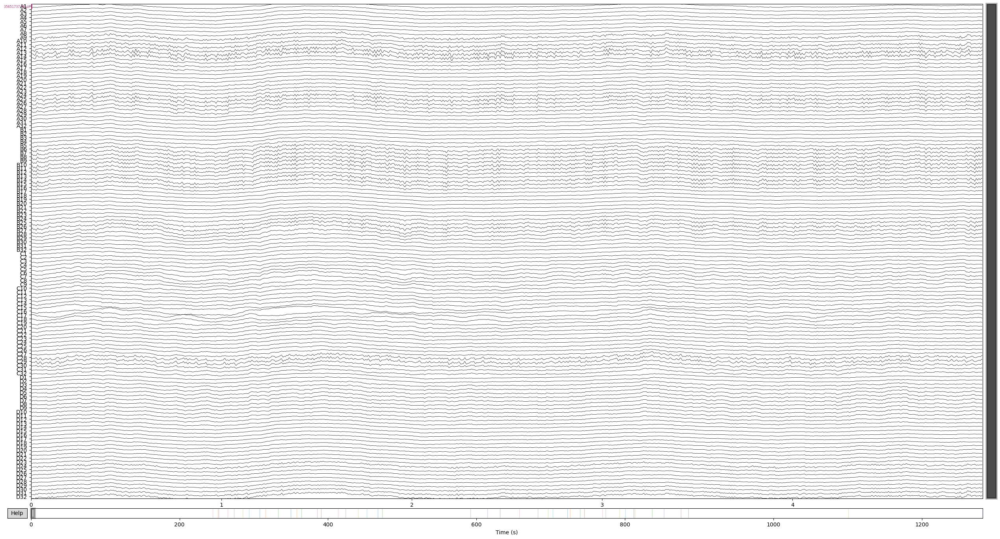

In [11]:
all_parads_raw_trimmed.plot(n_channels=128, duration=5, scalings='auto', clipping=None, butterfly=0)

#### ICA

In [7]:
all_epochs = create_epochs(all_parads_raw_trimmed)

Number of events:  1281
Created 1281 events at 1.0-second intervals
Events shape: (1281, 3) dtype: int64
Not setting metadata
1281 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1281 events and 513 original time points ...
1 bad epochs dropped


In [8]:
def get_ica(raw, n_channels, bad_channels):
    n_components_ica = n_channels - len(bad_channels)
    ica_eeg = mne.preprocessing.ICA(n_components=n_components_ica, random_state=68)
    ica_eeg.fit(raw)
    return ica_eeg

In [17]:
channels_n = 128
bad_ch = all_parads_raw_filt.info["bads"]
ica_all = get_ica(all_parads_raw_trimmed, n_channels=channels_n, bad_channels=bad_ch)

Fitting ICA to data using 128 channels (please be patient, this may take a while)
Selecting by number: 90 components


c:\Users\specsdcn\anaconda3\envs\pdoc\Lib\site-packages\sklearn\decomposition\_fastica.py:127: ConvergenceWarning: FastICA did not converge. Consider increasing tolerance or the maximum number of iterations.
  warnings.warn(


Fitting ICA took 1578.4s.


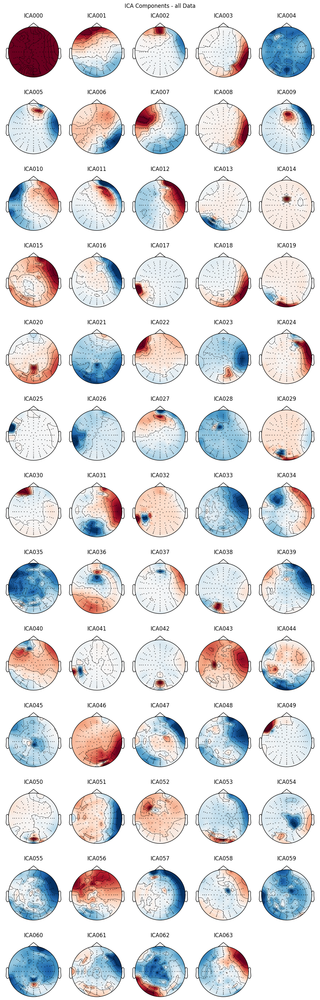

In [18]:
ica_all.plot_components(inst=all_epochs, picks=range(0, 64), title="ICA Components - all Data")

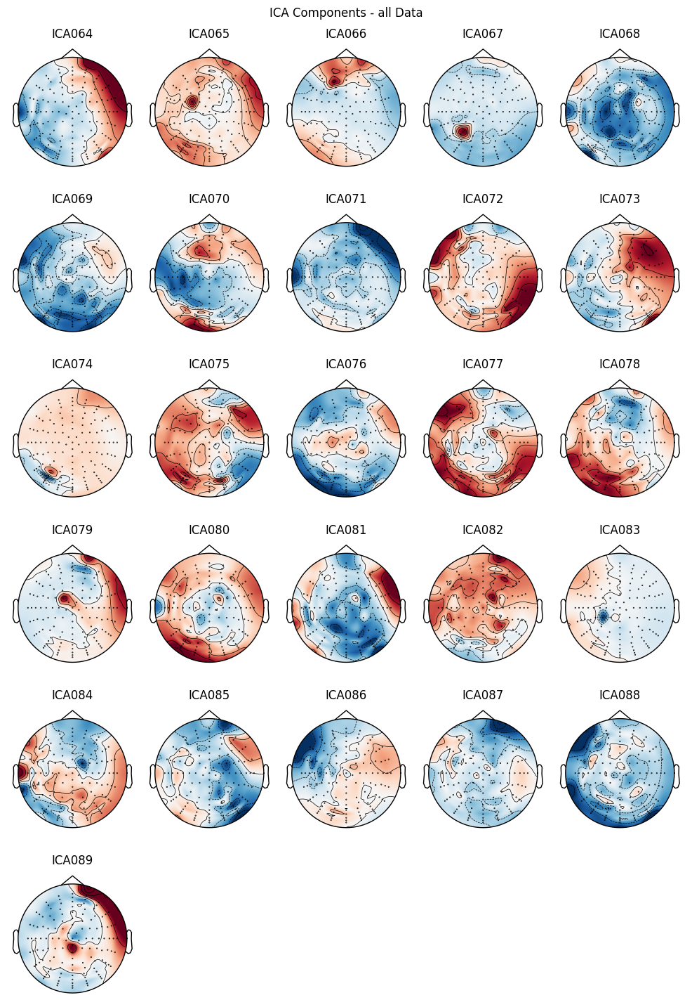

In [19]:
ica_all.plot_components(inst=all_epochs, picks=range(64, channels_n-len(bad_ch)), title="ICA Components - all Data")

In [20]:
ica_all_path = path_analysis_data_new + "sub-10/ica_all.fif"
ica_all.save(ica_all_path, overwrite=0)

eeg_all_ica_cleaned = ica_all.apply(all_parads_raw_trimmed)

ica_all_cleaned_path = "sub-10/eeg_all_ica_cleaned.fif"
store_mne_raw(eeg_all_ica_cleaned, path_analysis_data_new, ica_all_cleaned_path, ovwrite=0)

Writing ICA solution to D:\Taran\OneDrive - Radboud Universiteit\Documents\pdoc_data_analysis\analysis_data\sub-10\ica_all.fif...
Applying ICA to Raw instance


C:\Users\specsdcn\AppData\Local\Temp\ipykernel_19912\1872694462.py:2: RuntimeWarning: This filename (D:/Taran/OneDrive - Radboud Universiteit/Documents/pdoc_data_analysis/analysis_data/sub-10/ica_all.fif) does not conform to MNE naming conventions. All ICA files should end with -ica.fif, -ica.fif.gz, _ica.fif or _ica.fif.gz
  ica_all.save(ica_all_path, overwrite=0)


    Transforming to ICA space (90 components)
    Zeroing out 14 ICA components
    Projecting back using 128 PCA components
Writing D:\Taran\OneDrive - Radboud Universiteit\Documents\pdoc_data_analysis\analysis_data\sub-10\eeg_all_ica_cleaned.fif


C:\Users\specsdcn\AppData\Local\Temp\ipykernel_19912\2535818631.py:7: RuntimeWarning: This filename (D:\Taran\OneDrive - Radboud Universiteit\Documents\pdoc_data_analysis\analysis_data\sub-10\eeg_all_ica_cleaned.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  eeg_filtered.save(path_folder + path_data, overwrite=ovwrite)


Closing D:\Taran\OneDrive - Radboud Universiteit\Documents\pdoc_data_analysis\analysis_data\sub-10\eeg_all_ica_cleaned.fif
[done]


In [22]:
path_analysis_data_new

'D:/Taran/OneDrive - Radboud Universiteit/Documents/pdoc_data_analysis/analysis_data/'

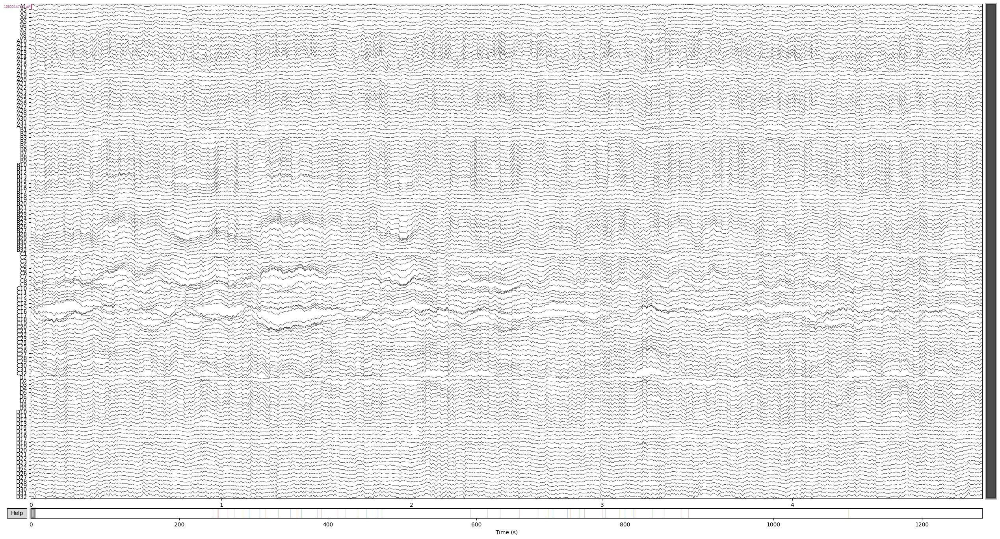

In [21]:
eeg_all_ica_cleaned.plot(n_channels=128, duration=5, scalings='auto', clipping=None, butterfly=0)